#### 1. Random Value Imputation
#### 2. Missing Indicator
#### 3. Automatic selection 

In [1]:
import pandas as pd
import numpy as np 

from sklearn.model_selection import train_test_split
 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("./train (3).csv" , usecols=['Age' , 'Fare' , 'Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

77    NaN
868   NaN
334   NaN
295   NaN
792   NaN
       ..
674   NaN
466   NaN
584   NaN
527   NaN
168   NaN
Name: Age_imputed, Length: 148, dtype: float64

In [10]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_6621/3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_6621/3090101260.

In [11]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,23.0
493,71.0,49.5042,71.0
527,NaN,221.7792,26.0


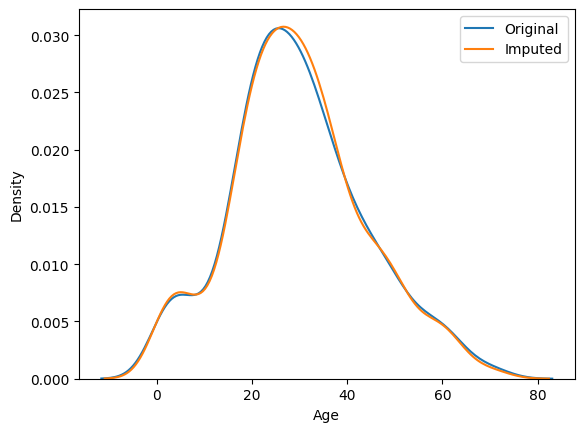

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

plt.legend()
plt.show()

In [15]:
print("Original variable variance : " , X_train['Age'].var())
print("Variance after random imputation : " , X_train['Age_imputed'].var())

Original variable variance :  204.34951339046142
Variance after random imputation :  198.9128491624394


In [16]:
X_train[['Fare' , 'Age' , 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,49.009345
Age,71.512440,204.349513,204.349513
Age_imputed,49.009345,204.349513,198.912849


<Axes: >

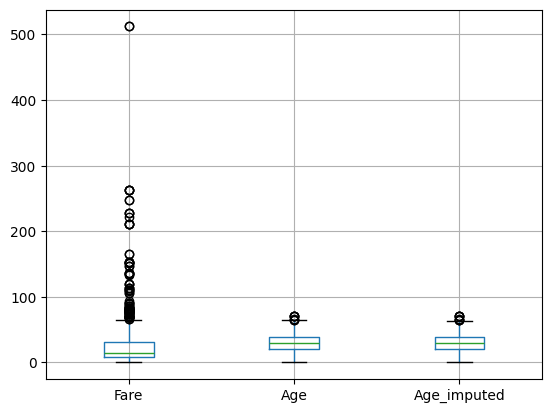

In [17]:
X_train[['Fare' , 'Age' , 'Age_imputed']].boxplot()

In [19]:
data = pd.read_csv("./house-train.csv",usecols=['GarageQual' , 'FireplaceQu','SalePrice'])

In [20]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [21]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [22]:
X = data 
y = data['SalePrice']

In [23]:
X_train,X_test,Y_test,Y_train = train_test_split(X,y,test_size=0.2 , random_state=2)

In [28]:
print(X_train.columns)

Index(['FireplaceQu', 'GarageQual', 'SalePrice', 'GarageQual_imputed',
       'FireplaceQu_imputed'],
      dtype='object')


In [24]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_train['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [25]:
X_train.sample()

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1015,NaN,TA,227000,NaN,NaN


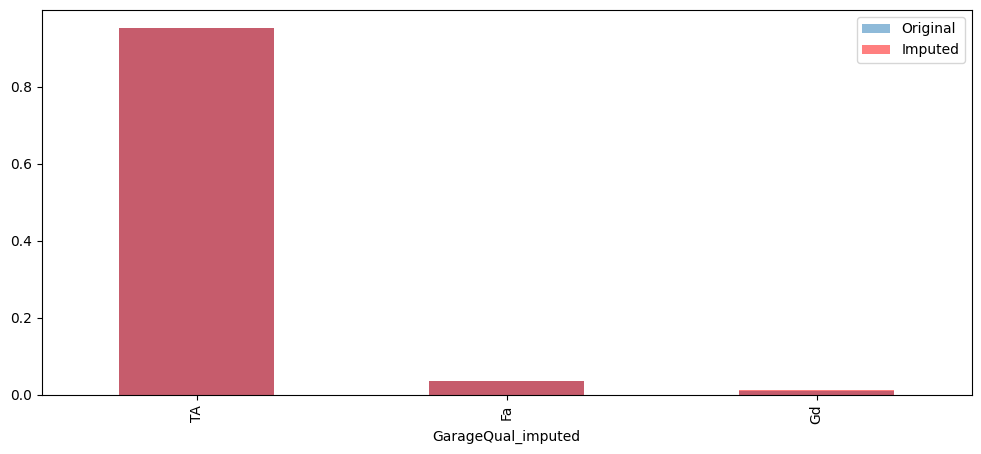

In [30]:
fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(111)

X_train['GarageQual'].value_counts(normalize=True).plot(
    kind='bar',
    ax=ax,
    alpha=0.5,
    label='Original'
)

X_train['GarageQual_imputed'].value_counts(normalize=True).plot(
    kind='bar',
    ax=ax,
    alpha=0.5,
    color='red',
    label='Imputed'
)

plt.legend()
plt.show()

In [31]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ], axis=1
)

temp.columns = ['original' , 'imputed']

In [32]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.035103
Gd,0.009973,0.013699
Po,0.000907,NaN
Ex,0.000907,NaN


In [33]:
temp = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
    ], axis=1
)

temp.columns = ['original' , 'imputed']

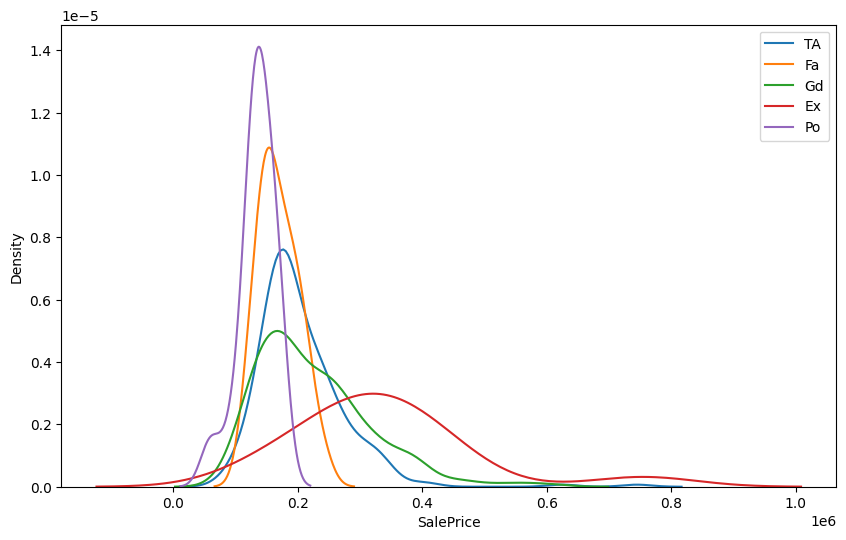

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.show()

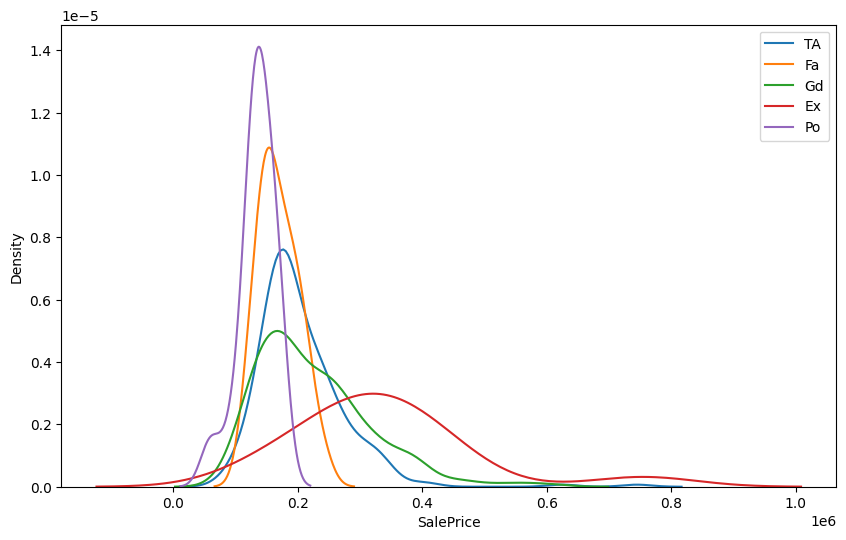

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.show()